<a href="https://colab.research.google.com/github/baramitha/bt4222/blob/main/notebooks/03_feature_engineering/03_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
user_filtered = pd.read_csv('/content/drive/My Drive/Colab Notebooks/user-filtered.csv.zip')
anime_filtered = pd.read_csv('/content/drive/My Drive/Colab Notebooks/anime-filtered.csv.zip')
users_details = pd.read_csv('/content/drive/My Drive/Colab Notebooks/users-details-2023.csv.zip')

print(f"User filtered shape: {user_filtered.shape}")
print(f"Anime filtered shape: {anime_filtered.shape}")
print(f"Users details shape: {users_details.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
User filtered shape: (109224747, 3)
Anime filtered shape: (14952, 25)
Users details shape: (731290, 16)


In [ ]:
user_filtered = pd.read_csv('/content/drive/My Drive/Colab Notebooks/user-filtered.csv.zip')
anime_filtered = pd.read_csv('/content/drive/My Drive/Colab Notebooks/anime-filtered.csv.zip')
users_details = pd.read_csv('/content/drive/My Drive/Colab Notebooks/users-details-2023.csv.zip')

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

Data Cleaning

In [ ]:
anime_clean = anime_filtered.copy()

# Standardize column names
anime_clean.columns = [col.strip().replace(' ', '_') for col in anime_clean.columns]
print(f"Original columns: {anime_clean.columns.tolist()}")

# Handle missing values
anime_clean['Score'] = pd.to_numeric(anime_clean['Score'], errors='coerce').fillna(0)
anime_clean['Episodes'] = anime_clean['Episodes'].replace('Unknown', 0)
anime_clean['Episodes'] = pd.to_numeric(anime_clean['Episodes'], errors='coerce').fillna(0)
anime_clean['Genres'] = anime_clean['Genres'].fillna('Unknown')
anime_clean['Type'] = anime_clean['Type'].fillna('Unknown')

# Remove duplicates
anime_clean = anime_clean.drop_duplicates(subset=['anime_id']).reset_index(drop=True)
print(f"Cleaned anime: {len(anime_clean):,} unique anime")

# 1.2 Clean Users Details Dataset
users_clean = users_details.copy()
users_clean.columns = [col.strip().replace(' ', '_') for col in users_clean.columns]

# Convert date columns
date_cols = ['Birthday', 'Joined']
for col in date_cols:
    if col in users_clean.columns:
        users_clean[col] = pd.to_datetime(users_clean[col], errors='coerce')

# Fill numeric columns
numeric_cols = ['Days_Watched', 'Mean_Score', 'Episodes_Watched']
for col in numeric_cols:
    if col in users_clean.columns:
        users_clean[col] = pd.to_numeric(users_clean[col], errors='coerce').fillna(0)

print(f"Cleaned users: {len(users_clean):,} users")

# 1.3 Clean Ratings Dataset
ratings_clean = user_filtered.copy()
ratings_clean.columns = ['user_id', 'anime_id', 'rating']

# Check for -1 ratings (watched but not rated)
print(f"Original ratings: {len(ratings_clean):,}")
neg_ratings = (ratings_clean['rating'] == -1).sum()
print(f"Ratings with -1: {neg_ratings:,} ({neg_ratings/len(ratings_clean)*100:.2f}%)")

# DECISION: Remove -1 ratings for cleaner explicit feedback
ratings_clean = ratings_clean[ratings_clean['rating'] != -1].copy()
print(f"After removing -1: {len(ratings_clean):,} ratings")


Original columns: ['anime_id', 'Name', 'Score', 'Genres', 'English_name', 'Japanese_name', 'sypnopsis', 'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity', 'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped']
Cleaned anime: 14,952 unique anime
Cleaned users: 731,290 users
Original ratings: 109,224,747
Ratings with -1: 0 (0.00%)
After removing -1: 109,224,747 ratings


Data Exploration to Determine Qauntile-based segmentation


📊 RATING COUNT DISTRIBUTION:
   Min: 1
   25th percentile: 96
   50th percentile (median): 224
   75th percentile: 436
   90th percentile: 741
   95th percentile: 1008
   99th percentile: 1803
   Max: 17546


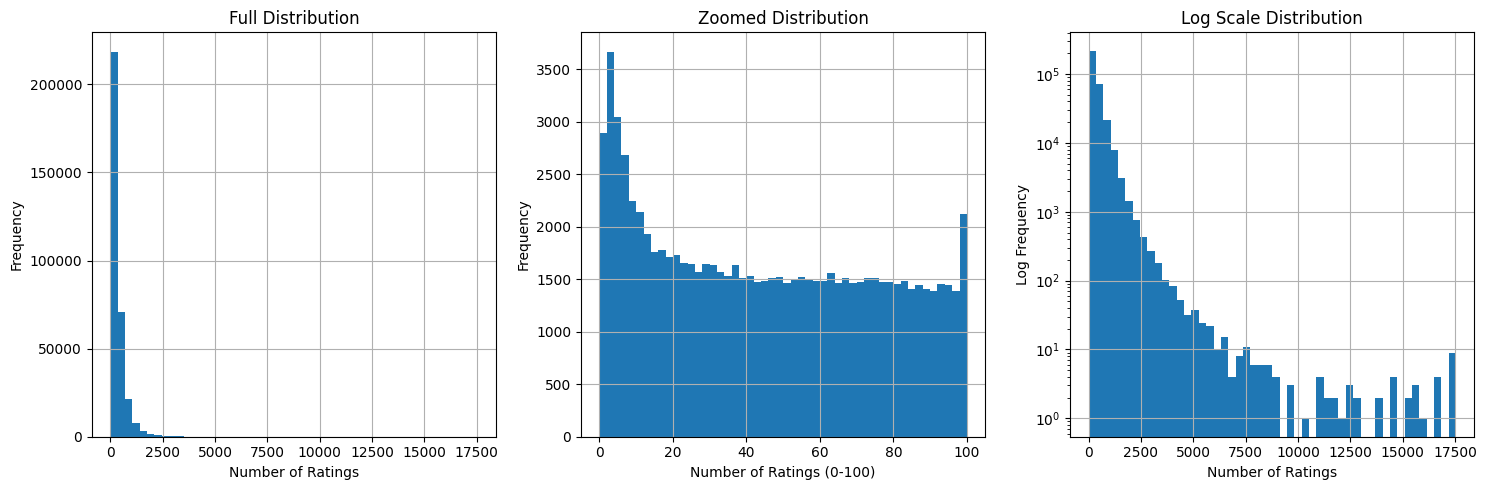

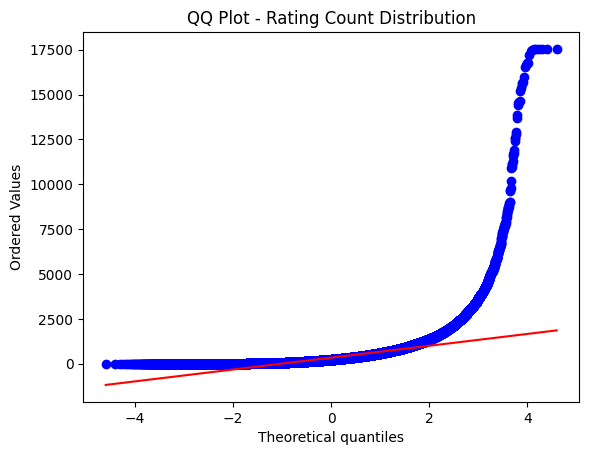

In [ ]:
#Justify user segementation using quantile-based segmentation:
# Calculate user rating counts
user_counts = ratings_clean.groupby('user_id').size().reset_index(name='rating_count')

# Get quantile statistics
quantiles = user_counts['rating_count'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("📊 RATING COUNT DISTRIBUTION:")
print(f"   Min: {user_counts['rating_count'].min()}")
print(f"   25th percentile: {quantiles[0.25]:.0f}")
print(f"   50th percentile (median): {quantiles[0.5]:.0f}")
print(f"   75th percentile: {quantiles[0.75]:.0f}")
print(f"   90th percentile: {quantiles[0.9]:.0f}")
print(f"   95th percentile: {quantiles[0.95]:.0f}")
print(f"   99th percentile: {quantiles[0.99]:.0f}")
print(f"   Max: {user_counts['rating_count'].max()}")

# Visualize distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
user_counts['rating_count'].hist(bins=50)
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.title('Full Distribution')

plt.subplot(1, 3, 2)
user_counts['rating_count'].hist(bins=50, range=(0, 100))
plt.xlabel('Number of Ratings (0-100)')
plt.ylabel('Frequency')
plt.title('Zoomed Distribution')

plt.subplot(1, 3, 3)
user_counts['rating_count'].hist(bins=50, log=True)
plt.xlabel('Number of Ratings')
plt.ylabel('Log Frequency')
plt.title('Log Scale Distribution')

plt.tight_layout()
plt.show()

# QQ plot to check distribution
from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(user_counts['rating_count'], dist="norm", plot=plt)
plt.title('QQ Plot - Rating Count Distribution')
plt.show()

In [ ]:
# Data-driven thresholds based on YOUR distribution's quartiles
LOW_THRESHOLD  = 96    # 25th percentile — below this is genuinely sparse
HIGH_THRESHOLD = 436   # 75th percentile — above this is a true power user

def assign_segment(n):
    if n <= LOW_THRESHOLD:
        return 'low'
    elif n <= HIGH_THRESHOLD:
        return 'mid'
    else:
        return 'high'

user_counts['segment'] = user_counts['rating_count'].apply(assign_segment)

# This will give you roughly 25% low, 50% mid, 25% power users by count
# But the ROW counts will still be skewed — verify this below
print(user_counts['segment'].value_counts())

segment
mid     162380
low      82101
high     81289
Name: count, dtype: int64


In [ ]:
# Define user IDs per segment from user_counts
# (user_counts must already exist from your earlier distribution analysis cell)
low_users   = user_counts[user_counts['segment'] == 'low']['user_id']
mid_users   = user_counts[user_counts['segment'] == 'mid']['user_id']
high_users = user_counts[user_counts['segment'] == 'high']['user_id']

print(f"Segment sizes before sampling:")
print(f"   Low:   {len(low_users):,} users")
print(f"   Mid:   {len(mid_users):,} users")
print(f"   High: {len(high_users):,} users")

# Sample — keep all low, 50% mid, 25% power
sampled_users = pd.concat([
    low_users,
    mid_users.sample(frac=0.50, random_state=42),
    high_users.sample(frac=0.25, random_state=42)
])

print(f"\nTotal sampled users: {sampled_users.nunique():,}")

# Filter ratings_clean down to only the sampled users' rows
sampled = ratings_clean[ratings_clean['user_id'].isin(sampled_users)].copy()

# Attach segment label to each row using user_counts as the lookup table
sampled['segment'] = sampled['user_id'].map(
    user_counts.set_index('user_id')['segment']
)
# ── Verification ─────────────────────────────────────────────────────────
print("\nUsers per segment:")
print(sampled.groupby('segment')['user_id'].nunique())

print("\nRows per segment:")
print(sampled.groupby('segment').size())

# This row share is the most important number — it reflects what your model
# actually trains on. If 'power' exceeds ~60%, reduce its sampling fraction.
print("\nRow share per segment (what your model actually sees):")
print((sampled.groupby('segment').size() / len(sampled) * 100).round(1))

Segment sizes before sampling:
   Low:   82,101 users
   Mid:   162,380 users
   High: 81,289 users

Total sampled users: 183,613

Users per segment:
segment
high    20322
low     82101
mid     81190
Name: user_id, dtype: int64

Rows per segment:
segment
high    16774299
low      3521601
mid     19313224
dtype: int64

Row share per segment (what your model actually sees):
segment
high    42.3
low      8.9
mid     48.8
dtype: float64


In [ ]:
# Calculate rating counts per user
user_counts = ratings_clean.groupby('user_id').size().reset_index(name='rating_count')
print(f"\nTotal users with ratings: {len(user_counts):,}")

# Create segments
user_counts['segment'] = 'unknown'
user_counts.loc[user_counts['rating_count'] <=96, 'segment'] = 'low'
user_counts.loc[(user_counts['rating_count'] > 96) & (user_counts['rating_count'] <= 436), 'segment'] = 'medium'
user_counts.loc[user_counts['rating_count'] > 436, 'segment'] = 'high'

# Segment statistics
segment_stats = user_counts['segment'].value_counts()
print(f"\n USER SEGMENTS (CLEANED DATA):")
print(f"Low (96<= ratings):  {segment_stats.get('low', 0):,} users")
print(f"Medium (66-436):      {segment_stats.get('medium', 0):,} users")
print(f"High (>436):         {segment_stats.get('high', 0):,} users")

# Store segment lists for sampling
low_users = user_counts[user_counts['segment'] == 'low']['user_id'].tolist()
med_users = user_counts[user_counts['segment'] == 'medium']['user_id'].tolist()
high_users = user_counts[user_counts['segment'] == 'high']['user_id'].tolist()

print(f"\n SEGMENT BREAKDOWN:")
print(f"Low:  {len(low_users):,} users ({len(low_users)/len(user_counts)*100:.1f}%)")
print(f"Med:  {len(med_users):,} users ({len(med_users)/len(user_counts)*100:.1f}%)")
print(f"High: {len(high_users):,} users ({len(high_users)/len(user_counts)*100:.1f}%)")


Total users with ratings: 325,770

 USER SEGMENTS (CLEANED DATA):
Low (96<= ratings):  82,101 users
Medium (66-436):      162,380 users
High (>436):         81,289 users

 SEGMENT BREAKDOWN:
Low:  82,101 users (25.2%)
Med:  162,380 users (49.8%)
High: 81,289 users (25.0%)


Sub-sampling

In [ ]:
print(users_clean.columns.tolist())

['Mal_ID', 'Username', 'Gender', 'Birthday', 'Location', 'Joined', 'Days_Watched', 'Mean_Score', 'Watching', 'Completed', 'On_Hold', 'Dropped', 'Plan_to_Watch', 'Total_Entries', 'Rewatched', 'Episodes_Watched']


In [ ]:
sampling_ratios = {
    'low': 1.0,#Keep all low-users (extension of proj)
    'med': 0.5,#50% of medium-users
    'high': 0.25#25% of high-users (main focus)
}

#Sample users from each segment
np.random.seed(42)
sampled_low = low_users#Keep all
sampled_med = np.random.choice(med_users, size=int(len(med_users) * sampling_ratios['med']), replace=False).tolist() if med_users else []
sampled_high = np.random.choice(high_users, size=int(len(high_users) * sampling_ratios['high']), replace=False).tolist() if high_users else []

sampled_users = sampled_low + sampled_med + sampled_high

print(f"\nSAMPLED USERS:")
print(f"Low:  {len(sampled_low):,}")
print(f"Med:  {len(sampled_med):,}")
print(f"High: {len(sampled_high):,}")
print(f"TOTAL: {len(sampled_users):,} users ({len(sampled_users)/len(user_counts)*100:.1f}% of all users)")

# Filter ratings to sampled users
ratings_sampled = ratings_clean[ratings_clean['user_id'].isin(sampled_users)].copy()
print(f"Sampled ratings: {len(ratings_sampled):,} ({len(ratings_sampled)/len(ratings_clean)*100:.1f}% of all ratings)")

# Filter user details to sampled users
users_sampled = users_clean[users_clean['Mal_ID'].isin(sampled_users)].copy()
print(f"Sampled user details: {len(users_sampled):,}")



SAMPLED USERS:
Low:  82,101
Med:  81,190
High: 20,322
TOTAL: 183,613 users (56.4% of all users)
Sampled ratings: 39,585,807 (36.2% of all ratings)
Sampled user details: 153,288


Feature Enginnering

In [ ]:
num_ratings = (
    ratings_sampled
    .groupby('user_id')['rating']
    .count()
    .reset_index(name='num_ratings')
)

print(num_ratings.head())

# compute average rating that a user has given to all anime
# average rating per user
avg_rating = (
    ratings_sampled
    .groupby('user_id', as_index=False)['rating']
    .mean()
    .rename(columns={'rating': 'avg_rating'})
)
print(avg_rating.head())

# rating std per user
rating_std = (
    ratings_sampled
    .groupby('user_id', as_index=False)['rating']
    .std()
    .rename(columns={'rating': 'rating_std'})
)
rating_std['rating_std'] = rating_std['rating_std'].fillna(0)
print(rating_std.head())

# average popularity of anime rated by each user
anime_pop = anime_clean[['anime_id', 'Popularity']].copy()

ratings_popularity = ratings_sampled[['user_id', 'anime_id']].merge(
    anime_pop,
    on='anime_id',
    how='left'
)

avg_popularity_rated = (
    ratings_popularity
    .groupby('user_id', as_index=False)['Popularity']
    .mean()
    .rename(columns={'Popularity': 'avg_popularity_rated'})
)
print(avg_popularity_rated.head())

del ratings_popularity
del anime_pop

# Combine User-Level Features
user_features = num_ratings.merge(avg_rating, on='user_id', how='left')
user_features = user_features.merge(rating_std, on='user_id', how='left')
user_features = user_features.merge(avg_popularity_rated, on='user_id', how='left')

print(user_features.head())


# Number of Ratings Received by Each Anime
num_scores = (
    ratings_sampled
    .groupby('anime_id')['rating']
    .count()
    .reset_index(name='num_scores')
)

print(num_scores.head())

# Sentiment Derived from Rating
def map_sentiment(rating):
    if rating <= 5:
        return 'Negative'
    elif rating <= 8:
        return 'Neutral'
    else:
        return 'Positive'

ratings_sampled['sentiment'] = ratings_sampled['rating'].apply(map_sentiment)

print(ratings_sampled[['user_id', 'anime_id', 'rating', 'sentiment']].head())


   user_id  num_ratings
0        0           74
1        1          139
2        2          494
3        5          194
4        7          156
   user_id  avg_rating
0        0    4.810811
1        1    6.776978
2        2    0.957490
3        5    1.927835
4        7    4.608974
   user_id  rating_std
0        0    3.988599
1        1    3.137070
2        2    2.678177
3        5    3.565079
4        7    3.999312
   user_id  avg_popularity_rated
0        0           1607.729730
1        1            515.323741
2        2           3219.554656
3        5           1236.943299
4        7            545.512821
   user_id  num_ratings  avg_rating  rating_std  avg_popularity_rated
0        0           74    4.810811    3.988599           1607.729730
1        1          139    6.776978    3.137070            515.323741
2        2          494    0.957490    2.678177           3219.554656
3        5          194    1.927835    3.565079           1236.943299
4        7          156    4.608

In [ ]:
# compute average rating that a user has given to all anime
avg_rating = (
    ratings_clean
    .groupby('user_id')['rating']
    .mean()
    .reset_index(name='avg_rating')
)
print(user_counts.head())

rating_std = (
    ratings_clean
    .groupby('user_id')['rating']
    .std()
    .reset_index(name='rating_std')
)

# fill NaN for users with only 1 rating
rating_std['rating_std'] = rating_std['rating_std'].fillna(0)

print(rating_std.head())




# Step 1: Drop existing Popularity columns to avoid confusion/duplicates
cols_to_drop = [c for c in ratings_sampled.columns if 'Popularity' in c]
ratings_sampled = ratings_sampled.drop(columns=cols_to_drop)

# Step 2: Create mapping reference from anime_clean
anime_pop_map = anime_clean[['anime_id', 'Popularity']]

# Step 3: Perform left merge to bring in fresh Popularity data
ratings_sampled = ratings_sampled.merge(anime_pop_map, on='anime_id', how='left')

# Step 4: Verify results
print(f"Columns in ratings_sampled: {ratings_sampled.columns.tolist()}")
print(f"Missing popularity values: {ratings_sampled['Popularity'].isna().sum()}")
display(ratings_sampled.head())


   user_id  rating_count segment
0        0            74     low
1        1           139  medium
2        2           494    high
3        3           358  medium
4        4           156  medium
   user_id  rating_std
0        0    3.988599
1        1    3.137070
2        2    2.678177
3        3    2.477396
4        4    3.253471
Columns in ratings_sampled: ['user_id', 'anime_id', 'rating', 'sentiment', 'Popularity']
Missing popularity values: 26646


,user_id,anime_id,rating,sentiment,Popularity
0,0,67,9,Positive,940.0
1,0,6702,7,Neutral,32.0
2,0,242,10,Positive,2742.0
3,0,4898,0,Negative,92.0
4,0,21,10,Positive,31.0


In [ ]:
# Group by user_id and calculate mean popularity
user_mean_popularity = ratings_sampled.groupby('user_id')['Popularity'].mean().reset_index()

# Rename the column for clarity
user_mean_popularity = user_mean_popularity.rename(columns={'Popularity': 'mean_anime_popularity'})

# Verify the results
print("Mean Anime Popularity per User calculated.")
print(f"New DataFrame shape: {user_mean_popularity.shape}")
display(user_mean_popularity.head())

Mean Anime Popularity per User calculated.
New DataFrame shape: (183613, 2)


,user_id,mean_anime_popularity
0,0,1607.729730
1,1,515.323741
2,2,3219.554656
3,5,1236.943299
4,7,545.512821


In [ ]:
# Ensure ratings_sampled is available and process the mean popularity
# Based on previous logic in the notebook:
# 1. Define sampling ratios
sampling_ratios = {'low': 1.0, 'med': 0.5, 'high': 0.25}

# 2. Re-create the sampled users and ratings if lost in state
np.random.seed(42)
sampled_low = low_users
sampled_med = np.random.choice(med_users, size=int(len(med_users) * sampling_ratios['med']), replace=False).tolist()
sampled_high = np.random.choice(high_users, size=int(len(high_users) * sampling_ratios['high']), replace=False).tolist()
sampled_users_list = sampled_low + sampled_med + sampled_high

# 3. Filter and prepare ratings_sampled with Popularity mapping
ratings_sampled = ratings_clean[ratings_clean['user_id'].isin(sampled_users_list)].copy()
anime_pop_map = anime_clean[['anime_id', 'Popularity']]
ratings_sampled = ratings_sampled.merge(anime_pop_map, on='anime_id', how='left')

# 4. Group by user_id and calculate mean popularity
user_mean_popularity = ratings_sampled.groupby('user_id')['Popularity'].mean().reset_index()

# 5. Rename the column for clarity
user_mean_popularity = user_mean_popularity.rename(columns={'Popularity': 'mean_anime_popularity'})

# Verify the results
print("Mean Anime Popularity per User calculated.")
print(f"New DataFrame shape: {user_mean_popularity.shape}")
display(user_mean_popularity.head())


Mean Anime Popularity per User calculated.
New DataFrame shape: (183613, 2)


,user_id,mean_anime_popularity
0,0,1607.729730
1,1,515.323741
2,2,3219.554656
3,5,1236.943299
4,7,545.512821


In [ ]:
import numpy as np
import pandas as pd

# 1. Define sampling ratios and ensure inputs are available
sampling_ratios = {'low': 1.0, 'med': 0.5, 'high': 0.25}

# 2. Re-create the sampled users and ratings
np.random.seed(42)
sampled_low = low_users
sampled_med = np.random.choice(med_users, size=int(len(med_users) * sampling_ratios['med']), replace=False).tolist()
sampled_high = np.random.choice(high_users, size=int(len(high_users) * sampling_ratios['high']), replace=False).tolist()
sampled_users_list = sampled_low + sampled_med + sampled_high

# 3. Filter and prepare ratings_sampled with Popularity mapping from anime_clean
ratings_sampled = ratings_clean[ratings_clean['user_id'].isin(sampled_users_list)].copy()
anime_pop_map = anime_clean[['anime_id', 'Popularity']]
ratings_sampled = ratings_sampled.merge(anime_pop_map, on='anime_id', how='left')

# 4. Group by user_id and calculate mean popularity
user_mean_popularity = ratings_sampled.groupby('user_id')['Popularity'].mean().reset_index()

# 5. Rename the column for clarity
user_mean_popularity = user_mean_popularity.rename(columns={'Popularity': 'mean_anime_popularity'})

# Verify the results
print("Mean Anime Popularity per User calculated.")
print(f"New DataFrame shape: {user_mean_popularity.shape}")
display(user_mean_popularity.head())


Mean Anime Popularity per User calculated.
New DataFrame shape: (183613, 2)


,user_id,mean_anime_popularity
0,0,1607.729730
1,1,515.323741
2,2,3219.554656
3,5,1236.943299
4,7,545.512821


In [ ]:
import numpy as np
import pandas as pd
import gc

# 1. Re-extract segment lists from user_counts (Variable #11 in kernel state)
# Note: Variable #11 uses 'mid', 'low', 'high' as segment labels
low_users_list = user_counts[user_counts['segment'] == 'low']['user_id'].tolist()
mid_users_list = user_counts[user_counts['segment'] == 'mid']['user_id'].tolist()
high_users_list = user_counts[user_counts['segment'] == 'high']['user_id'].tolist()

# 2. Define sampling ratios
sampling_ratios = {'low': 1.0, 'mid': 0.5, 'high': 0.25}

# 3. Re-create the sampled users
np.random.seed(42)
sampled_low = low_users_list
sampled_mid = np.random.choice(mid_users_list, size=int(len(mid_users_list) * sampling_ratios['mid']), replace=False).tolist()
sampled_high = np.random.choice(high_users_list, size=int(len(high_users_list) * sampling_ratios['high']), replace=False).tolist()
sampled_users_list = sampled_low + sampled_mid + sampled_high

# 4. Filter and prepare ratings_sampled with Popularity mapping from anime_clean
# Using ratings_clean (Variable #7) and anime_clean (Variable #1)
ratings_sampled = ratings_clean[ratings_clean['user_id'].isin(sampled_users_list)].copy()
anime_pop_map = anime_clean[['anime_id', 'Popularity']]
ratings_sampled = ratings_sampled.merge(anime_pop_map, on='anime_id', how='left')

# 5. Group by user_id and calculate mean popularity
user_mean_popularity = ratings_sampled.groupby('user_id')['Popularity'].mean().reset_index()

# 6. Rename the column for clarity
user_mean_popularity = user_mean_popularity.rename(columns={'Popularity': 'mean_anime_popularity'})

# Verify the results
print("Mean Anime Popularity per User calculated.")
print(f"New DataFrame shape: {user_mean_popularity.shape}")
display(user_mean_popularity.head())


Mean Anime Popularity per User calculated.
New DataFrame shape: (102423, 2)


,user_id,mean_anime_popularity
0,0,1607.729730
1,9,1067.333333
2,10,1890.480000
3,13,933.369231
4,17,1269.173401


In [ ]:
# Merge user_mean_popularity into users_clean
# Note: 'Mal_ID' in users_clean corresponds to 'user_id' in user_mean_popularity
users_clean = users_clean.merge(
    user_mean_popularity,
    left_on='Mal_ID',
    right_on='user_id',
    how='left'
)

# Drop the redundant 'user_id' column from the merge result
if 'user_id' in users_clean.columns:
    users_clean = users_clean.drop(columns=['user_id'])

# Check for missing values in the new feature (users not in the sampled set)
missing_count = users_clean['mean_anime_popularity'].isna().sum()
print(f"Users without mean popularity score: {missing_count:,}")

# Optional: Fill missing values with a global mean or 0 if preferred.
# Here we verify the distribution first.
print(f"Updated users_clean shape: {users_clean.shape}")
print("First 5 rows of updated users_clean:")
display(users_clean.head())

Users without mean popularity score: 645,807
Updated users_clean shape: (731290, 17)
First 5 rows of updated users_clean:


,Mal_ID,Username,Gender,Birthday,Location,Joined,Days_Watched,Mean_Score,Watching,Completed,On_Hold,Dropped,Plan_to_Watch,Total_Entries,Rewatched,Episodes_Watched,mean_anime_popularity
0,1,Xinil,Male,1985-03-04 00:00:00+00:00,California,2004-11-05 00:00:00+00:00,142.3,7.37,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0,NaN
1,3,Aokaado,Male,NaT,"Oslo, Norway",2004-11-11 00:00:00+00:00,68.6,7.34,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0,NaN
2,4,Crystal,Female,NaT,"Melbourne, Australia",2004-11-13 00:00:00+00:00,212.8,6.68,16.0,636.0,303.0,0.0,45.0,1000.0,10.0,12781.0,NaN
3,9,Arcane,NaN,NaT,NaN,2004-12-05 00:00:00+00:00,30.0,7.71,5.0,54.0,4.0,3.0,0.0,66.0,0.0,1817.0,1067.333333
4,18,Mad,NaN,NaT,NaN,2005-01-03 00:00:00+00:00,52.0,6.27,1.0,114.0,10.0,5.0,23.0,153.0,42.0,3038.0,652.900000
